### Tripartite DIQRNG
- explain how the protocol works
- explain why we're doing GHZ
- talk about the three sequences and how they're completely random
- reference the paper

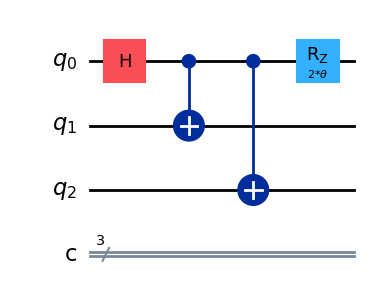

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
import numpy as np

"""Creates a 3-qubit GHZ state and applies measurements in the specified basis."""
qc = QuantumCircuit(3, 3)  # 3 qubits, 3 classical bits

# Step 1: Create GHZ state
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
qc.draw(output="mpl", idle_wires=False, style="iqp")

#Parametrised angle rotates along the Z axis since we are measuring in X and Y 
# Only apply to first qubit in order to create a phase 
theta = Parameter("$\\theta$")
qc.rz(2 * theta, 0)
# qc.rz(2 * theta, 1)
# qc.rz(2 * theta, 2)

number_of_phases = 21
phases = np.linspace(0, 2 * np.pi, number_of_phases)
# Phases need to be expressed as list of lists in order to work
individual_phases = [[ph] for ph in phases]

# Step 3: Measure qubits
qc.draw(output="mpl")


for each observable, we need to measure it in a different basis. perhaps add feature in code to apply different gates depending on the basis?

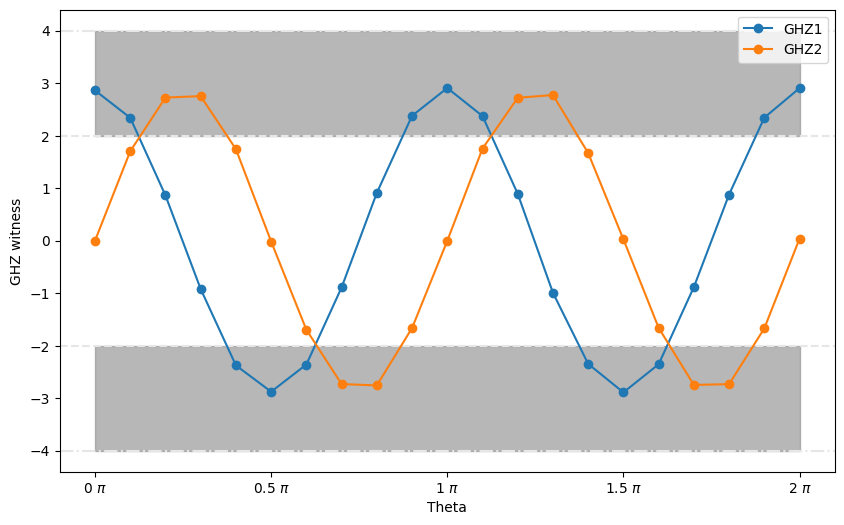

In [11]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

QiskitRuntimeService.save_account(

    channel="ibm_quantum",

    token="3b804182dcf5d92a78f5342e3c48bc71edd10a6e3a857928bd90f0c4fd2af986144fdb4b99551ef6c857b615e26a1186572c0aee4ec5d460427ca1884c7b5d26",

    set_as_default=True,

    # Use ⁠ overwrite=True ⁠ if you're updating your token.
    overwrite=True,
)

# Load saved credentials
service = QiskitRuntimeService()
backend = FakeManilaV2()
backend.name

observable1 = SparsePauliOp.from_list([("XXX", 1), ("XYY", -1), ("YXY", -1), ("YYX", -1)])
observable2 = SparsePauliOp.from_list([("YYY", -1), ("YXX", 1), ("XYX", 1), ("XXY", 1)])

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

ghz_circuit = pm.run(qc)
ghz_circuit.draw(output="mpl", idle_wires=False, style="iqp")

isa_observable1 = observable1.apply_layout(layout=ghz_circuit.layout)
isa_observable2 = observable2.apply_layout(layout=ghz_circuit.layout)

# To run on a local simulator:
# Use the StatevectorEstimator from qiskit.primitives instead.

estimator = Estimator(mode=backend)

pub = (
    ghz_circuit,  # ISA circuit
    [[isa_observable1], [isa_observable2]],  # ISA Observables
    individual_phases,  # Parameter values
)

job_result = estimator.run(pubs=[pub])
job = estimator.run(pubs=[pub])
job_result = job.result()
ghz1_est = job_result[0].data.evs[0]
ghz2_est = job_result[0].data.evs[1]

fig, ax = plt.subplots(figsize=(10, 6))

# results from hardware
ax.plot(phases / np.pi, ghz1_est, "o-", label="GHZ1", zorder=3)
ax.plot(phases / np.pi, ghz2_est, "o-", label="GHZ2", zorder=3)

# classical bound +-2
ax.axhline(y=2, color="0.9", linestyle="--")
ax.axhline(y=-2, color="0.9", linestyle="--")

# quantum bound, +-2√2
ax.axhline(y=4, color="0.9", linestyle="-.")
ax.axhline(y=-4, color="0.9", linestyle="-.")
ax.fill_between(phases / np.pi, 2, 4, color="0.6", alpha=0.7)
ax.fill_between(phases / np.pi, -2, -4, color="0.6", alpha=0.7)

# set x tick labels to the unit of pi
ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
ax.xaxis.set_major_locator(tck.MultipleLocator(base=0.5))

# set labels, and legend
plt.xlabel("Theta")
plt.ylabel("GHZ witness")
plt.legend()
plt.show()